# Terrestrial water storage (TWS) anomaly time series derived from GRACE


Authors: Kiana Karimi, Iniobong Benson and Roelof Rietbroek Jan 2025

# Intorduction and goal of the Tutorial:

In this exercise, the goal is to get started with a jupyter python notebook, and learn how to download GRACE level-2 data (monthly gravity field solution) from the ITSG dataset as follows.

To use this notebook, the shxarray package should be installed from https://github.com/ITC-Water-Resources/shxarray or from https://pypi.org/project/shxarray/

The data used in this tutorial is from ITSG Level-2 datasets https://www.tugraz.at/institute/ifg/downloads/gravity-field-models/itsg-grace2018#c194128

### Computing Terrestrial Water Storage:

Since 2002, the monthly gravity measurements provided by the Gravity Recovery and Climate Experiment (GRACE) twin satellites have been used in studying global and regional changes in Terrestrial Water Storage (TWS). TWS is the vertically integrated total amount of water stored on and beneath the land surface. It includes groundwater, soil moisture, surface water, snow and ice, and water stored in the atmosphere.
A monthly GRACE gravity field solution is expressed by a set of spherical harmonic (SH) coefficients complete to a certain degree named as Stokes coefficients. Stokes coefficients from the GRACE solutions (downloaded from ITSG in this tutorial) can be converted to Terrestrial Water Storage (TWS) anomaly.

In order to derive TWS anomaly from level-2 stokes coefficients, several processing steps are often needed to obtain good results. The steps are described as below:

* 01-  Apply degree corrections

* 02- Obtain time-anomalies by subtracting a static gravity field from the monthly solutions (more details about the static gravity filed models: https://icgem.gfz-potsdam.de/tom_longtime and https://ggos.org/item/global-gravity-field-models/)

* 03- Apply a filter to GRACE Level-2 data to minimize noise 

In [1]:
%env OPENBLAS_NUM_THREADS=4

env: OPENBLAS_NUM_THREADS=4


# Step 1: Load the necessary python modules

%load_ext autoreload 
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gzip
import shxarray
dataroot='~/shared/Hydrological-and-Environmental-Cycles-2024-1B/Roelof_TWS/data/'

# Step 2: Read monthly solutions Stokes coefficients form directory path

In [3]:
def load_icgem_files(datadir):

    gsm = []
    deg1_terms = []
    term_c20 = []
    files = os.listdir(datadir)

    for file in files:
        file_path = os.path.join(datadir, file)
        if "ITSG-Grace2018" in file:
            gsm.append(xr.open_dataset(file_path, engine="icgem"))
        if "c20" in file:
            term_c20.append(xr.open_dataset(file_path, engine="icgem"))
        elif "degree1" in file:
            deg1_terms.append(xr.open_dataset(file_path, engine="icgem"))  ## Depending on the gravitational spherical harmonic model, the engine can be = "gsmv6"

    if deg1_terms and term_c20:
        deg1_cnm = xr.concat(deg1_terms, dim="time").sortby("time")
        c20_cnm = xr.concat(term_c20, dim="time").sortby("time")
        return deg1_cnm, c20_cnm
    else:
        dsgsm = xr.concat(gsm, dim="time")
        dsgsm = dsgsm.sortby('time')
        return dsgsm

In [4]:

datadir = os.path.expanduser(os.path.join(dataroot,'monthly_solutions/monthly_n96'))

ds = load_icgem_files(datadir)
ds

<xarray.Dataset>
Dimensions:  (time: 162, nm: 9409)
Coordinates:
  * nm       (nm) object MultiIndex
  * n        (nm) int64 0 1 1 1 2 2 2 2 2 3 3 ... 96 96 96 96 96 96 96 96 96 96
  * m        (nm) int64 0 0 1 -1 0 1 -1 2 -2 ... -92 93 -93 94 -94 95 -95 96 -96
  * time     (time) datetime64[ns] 2002-04-15T12:00:00 ... 2017-06-15T12:00:00
Data variables:
    cnm      (time, nm) float64 1.0 0.0 0.0 ... 2.452e-10 -2.245e-09 1.527e-09
    sigcnm   (time, nm) float64 0.0 0.0 0.0 ... 5.098e-11 2.906e-11 2.797e-11
Attributes:
    nmaxfile:   96
    nmax:       96
    format:     icgem
    norm:       fully_normalized
    gm:         398600441500000.0
    re:         6378136.3
    modelname:  ITSG-Grace2018_n96_2009-12

# Step 3: Apply degree corrections

## Degree 1 terms correction
One problem of the monthly solutions is that they absence of degree-1 coefficients (ΔC10, ΔC11 and ΔS11), which correspond to the geocentre motion defined as the displacement of the center of mass of the whole Earth system (CM) with respect to the center of figure of the solid Earth (CF) .  Excluding the degree-1 contribution leads to significant errors in terrestrial water storage (TWS) estimates.

For this reason Degree 1 corrections from Satellite Laser Ranging measurements are used as a correction

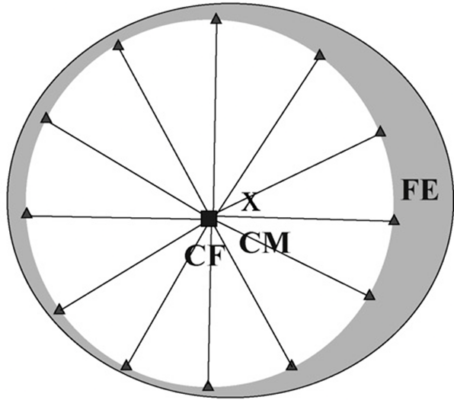

For some inspiration:
https://blogs.egu.eu/divisions/g/2024/01/19/bits-and-bites-of-geodesy-where-is-the-centre-of-the-earth-why-do-we-care/


## C20 coefficient correction 
Another problem of GRACE monthly solutions is that the C20 coefficient is subject to large uncertainties due to the GRACE orbital geometry and the systematic errors in the accelerometer data. Therefore, to estimate TWS  anomalies, we correct for these coefficients by replacing them with independently estimated degree-1 terms and C20 coefficient from  satellite laser ranging (SLR).

In [5]:
bkdatadir = os.path.expanduser(os.path.join(dataroot,'monthly_solutions/monthly_background'))

ds_deg1,ds_c20 = load_icgem_files(bkdatadir)

In [6]:
c20 = ds_c20.cnm.sel(n=2, m =0)
display(c20)
#replace C20 values for all time steps in the GRACE data
ds.cnm.loc[:,c20.nm]= c20.values

<xarray.DataArray 'cnm' (time: 162)>
array([-0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417, -0.00048417, -0.00048417, -0.00048417,
       -0.00048417, -0.00048417])
Coordinates:
    nm       object (2, 0)
    n        int64 2
    m        int64 0
  * time     (time) datetime64[ns] 2002-04-15T12:00:00 ... 2017-06-15T12:00:00
Attributes:
    units:      -
    long_name:  Stokes Coefficients
    gravtype:   stokes

In [7]:
deg1_terms=ds_deg1.sh.truncate(1,1) #only use degree 1 coefficients and get rid of degree 0
display(deg1_terms)
ds.cnm.loc[:,deg1_terms.nm]=deg1_terms.cnm

# or with the use of loops (slower)
# for m in [0, 1, -1]:
#     ds.cnm.loc[{'n': 1, 'm': m}] = deg1_terms.cnm.sel(n=1,m=m)

<xarray.Dataset>
Dimensions:  (time: 162, nm: 3)
Coordinates:
  * nm       (nm) object MultiIndex
  * n        (nm) int64 1 1 1
  * m        (nm) int64 0 1 -1
  * time     (time) datetime64[ns] 2002-04-15T12:00:00 ... 2017-06-15T12:00:00
Data variables:
    cnm      (time, nm) float64 6.217e-10 1.842e-10 ... -6.684e-11 -8.638e-11
Attributes:
    nmaxfile:   1
    nmax:       1
    format:     icgem
    norm:       fully_normalized
    gm:         398600441500000.0
    re:         6378136.3
    modelname:  model_degree1_2006-04

# Step 4: Read the time-invariable static gravity field data and subtract it from the monthly solutions

In [8]:
staticdatadir = os.path.expanduser(os.path.join(dataroot,'monthly_solutions/static'))

name= "ITSG-Grace2018s.gfc"
file_path = os.path.join(staticdatadir, name)
dsstatic = xr.open_dataset(file_path, engine="icgem")
dsstatic

<xarray.Dataset>
Dimensions:  (nm: 40401)
Coordinates:
  * nm       (nm) object MultiIndex
  * n        (nm) int64 0 1 1 1 2 2 2 2 2 ... 200 200 200 200 200 200 200 200
  * m        (nm) int64 0 0 1 -1 0 1 -1 2 ... -197 198 -198 199 -199 200 -200
Data variables:
    cnm      (nm) float64 ...
    sigcnm   (nm) float64 ...
Attributes:
    nmaxfile:   200
    nmax:       200
    format:     icgem
    norm:       fully_normalized
    gm:         398600441500000.0
    re:         6378136.3
    modelname:  ITSG-Grace2018s

In [9]:
ds["dcnm"]=ds.cnm-dsstatic.cnm

Filter degree zero as we do not need this coefficient in the derivation of TWS time series

In [10]:
ds1 = ds.sh.truncate(ds.sh.nmax, 1)

# Step 5: Calculate terrestrial water storage change in spectral domain

In this step, we calculate the TWS anomaly in the spectral domain. This allows us to focus on surface-level changes in terrestrial water storage and consider how gravity field properties outside the surface can influence the GRACE measurements.

In [11]:
datws=ds1.dcnm.sh.tws()
display(datws)

shxarray-INFO: /home/jovyan/.cache/shxarray_storage/Love/geoslurp_dump_llove.sql already exists, no need to download)


<xarray.DataArray 'tws' (time: 162, nm: 9408)>
array([[ 2.13225571e-02,  6.31603642e-03, -1.46070734e-02, ...,
        -3.80599647e-01, -1.10550524e-01,  1.34023377e-01],
       [-1.25740602e-03,  1.13329913e-02, -1.66096628e-02, ...,
         8.03981056e-02, -2.37433310e-03, -4.91293443e-01],
       [-1.89545740e-03,  1.47784819e-03,  1.02669347e-02, ...,
         7.28700069e-02, -4.68987949e-02, -7.08848019e-02],
       ...,
       [ 1.22721888e-02,  9.67697444e-03, -4.97693244e-03, ...,
         1.73845228e-01, -1.29881353e-02, -3.46689078e-02],
       [ 1.91249167e-04,  1.15255401e-02, -9.62223560e-03, ...,
        -2.75112923e-02,  3.00423718e-02,  6.89224888e-02],
       [-9.21925667e-03, -2.29233654e-03, -2.96261263e-03, ...,
        -6.81238770e-02, -2.64771303e-02, -1.18127543e-02]])
Coordinates:
  * nm       (nm) object MultiIndex
  * n        (nm) int64 1 1 1 2 2 2 2 2 3 3 3 ... 96 96 96 96 96 96 96 96 96 96
  * m        (nm) int64 0 1 -1 0 1 -1 2 -2 0 ... -92 93 -93 94 -94 95 -95 96 -96
  * time     (time) datetime64[ns] 2002-04-15T12:00:00 ... 2017-06-15T12:00:00
Attributes:
    units:      m
    long_name:  Total water storage
    gravtype:   tws

# Step 6: Calculate terrestrial water storage change in spatial domain globally

In [12]:
dsgrd=datws.sh.synthesis().to_dataset(name="tws")

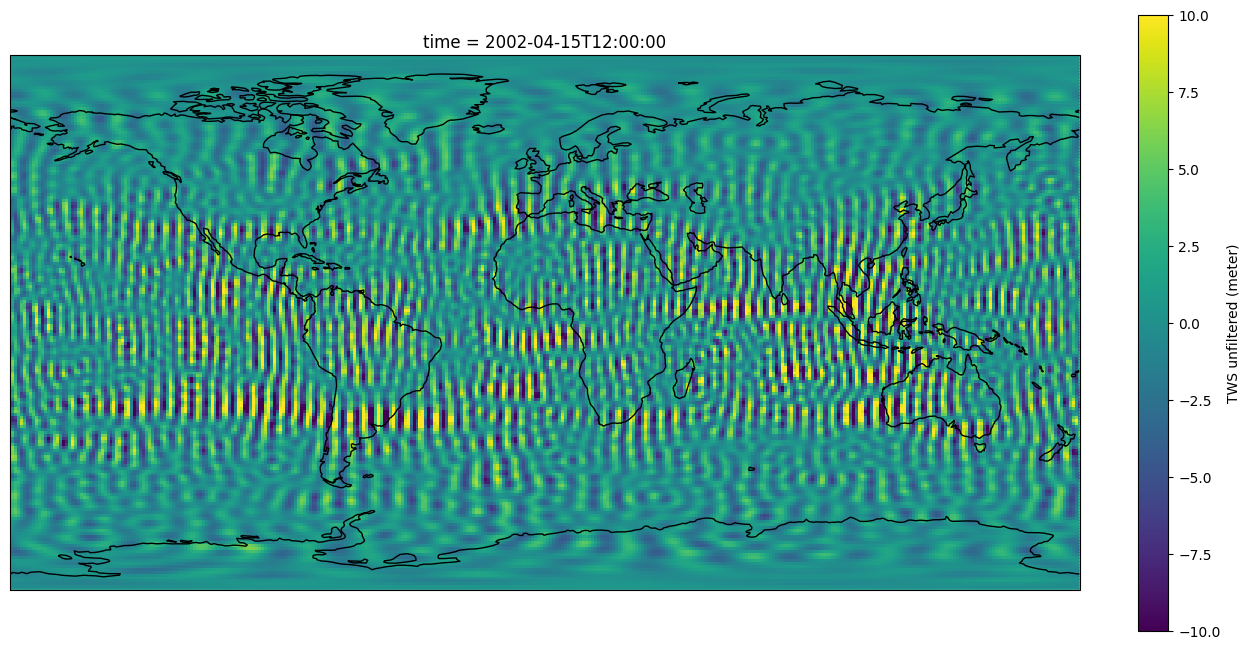

In [15]:
islice=0

fig, axs = plt.subplots(figsize=(15, 8),subplot_kw= dict(projection=ccrs.PlateCarree()))

# Add colorbar with adjusted size

im0=dsgrd.tws[:,:,islice].plot(ax=axs,vmin=-10, vmax =10,add_colorbar=False)
plt.colorbar(im0, fraction=0.03).set_label("TWS unfiltered (meter)")
axs.coastlines()   # Add coastlines

dsgrd
lats = dsgrd['lat'].values
lons = dsgrd['lon'].values

# Step 7: Reduce errors by applying filters in the spectral domain

In [16]:
# Guassian isotropic filter with 350 km Halfwidth
dsgrd["twsgauss"]=datws.sh.filter('Gauss350').sh.synthesis()
# Anisotropic decorrelation filter
dsgrd["twsddk"]=datws.sh.filter('DDK5').sh.synthesis()


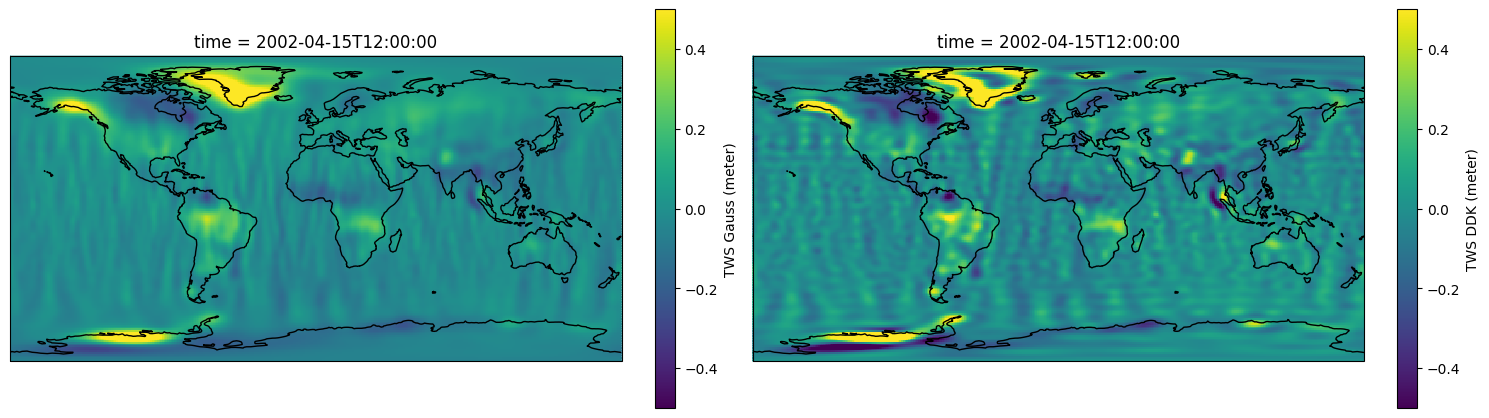

In [17]:
# Create subplots and set the axes using the Cartopy map projection
fig, axs = plt.subplots(ncols=2,nrows=1,figsize=(15, 8),subplot_kw= dict(projection=ccrs.PlateCarree()))

    
vmin = -0.5
vmax = 0.5
islice = 0

# Plot the TWS anomaly time series filtered using a Gaussian filter
im1 = dsgrd.twsgauss[:, :, islice].plot(ax=axs[0], vmin=vmin, vmax=vmax, add_colorbar=False)
# Add colorbar with adjusted size
plt.colorbar(im1, fraction=0.03).set_label("TWS Gauss (meter)")
axs[0].coastlines()   # Add coastlines

# Plot the TWS anomaly time series filtered using a DDk filter
im2 = dsgrd.twsddk[:, :, islice].plot(ax=axs[1], vmin=vmin, vmax=vmax, add_colorbar=False)
axs[1].coastlines()  # Add coastlines
plt.colorbar(im2, fraction=0.03).set_label("TWS DDK (meter)")


# Adjust layout
plt.tight_layout()

# Step 8: Save TWS time series to use it for the Assignment

In [ ]:
dsgrd.to_netcdf("TWS.nc")

# Step 9: Display the effect of filtering on the degree variances of a solution

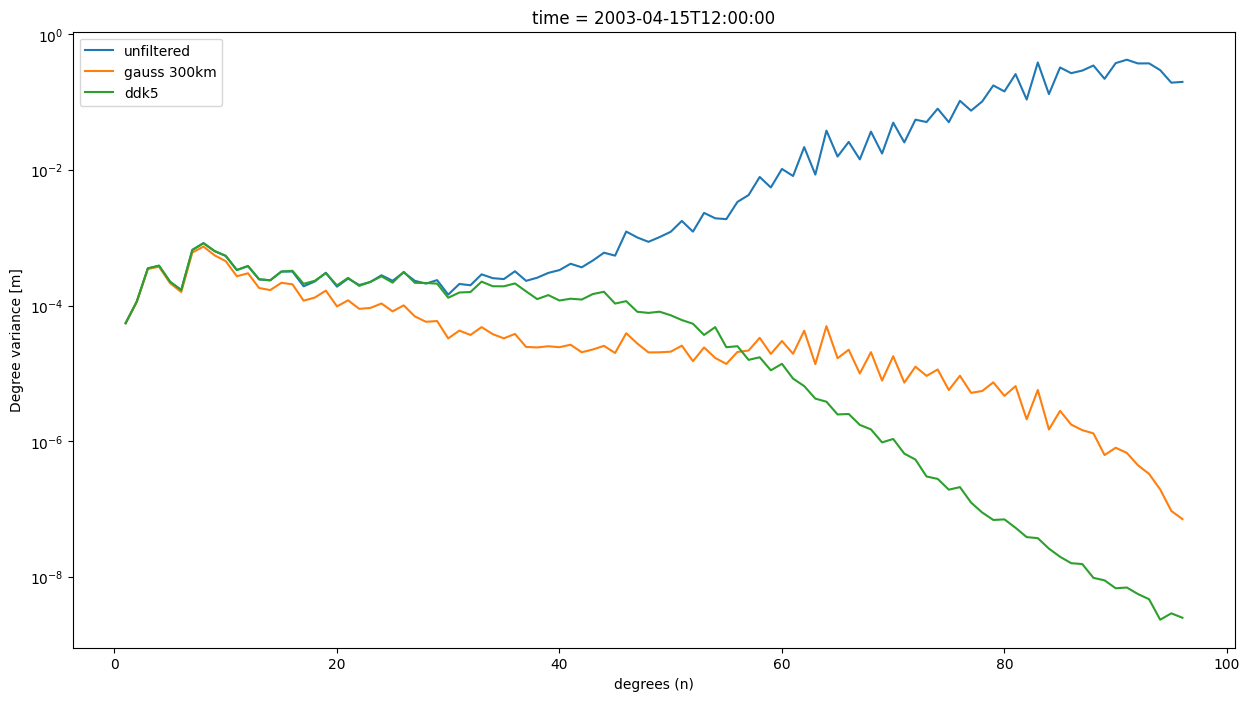

In [65]:

fig, ax = plt.subplots(figsize=(15, 8))

# dstws=ds1.dcnm.to_dataset(name='tws')

dstws=datws.to_dataset(name='tws')

dstws["twsgauss300"]=dstws.tws.sh.filter('Gauss300')
# Anisotropic decorrelation filter
dstwsddk=dstws.tws.sh.filter('DDK5',truncate=False)

twsdv=dstws.tws[islice,:].sh.degvar(False)

twsgauss300dv=dstws.twsgauss300[islice,:].sh.degvar(False)
twsddk5dv=dstwsddk[islice,:].sh.degvar(False)


twsdv.plot(ax=ax,label='unfiltered')

twsgauss300dv.plot(ax=ax,label='gauss 300km')
twsddk5dv.plot(ax=ax,label='ddk5')
plt.legend()
ax.set_yscale('log')




# Step 10 Write a list of bullet points on what you learned from this tutorial and link it to the topics of the lecture

# Step 11: Use other filters and derive grid based TWS anomaly time series

# Hints & Tips:

More info on the Anisotropic filters can be founds [here](https://shxarray.wobbly.earth/latest/notebooks/visualize_filter.html)  and [here](https://github.com/strawpants/GRACE-filter)

You can to change the filter strengths:
* 01- Use three DDK filters with degree power law and explain your results (e.g., DDK3, DDk4, ...)

* 02- Do the same step for the Gaussian filter with different radius values and explain your results (e.g., Gauss250, Gauss400, ...)